Participant Name: Ayoisegun Akinsola Kaggle Username: ayoisegunakinsola Cohort: DSN Bootcamp 2026 Date: September 2026

# Section 1: Setup and Data Loading


## Section 1.1 — Environment Setup

Load core libraries for data manipulation (pandas, numpy), visualization (matplotlib, seaborn), modeling (sklearn, xgboost, lightgbm), and CV utilities. Suppress warnings for cleaner output.



In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Make plots look nice
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(" All libraries loaded successfully!")

 All libraries loaded successfully!


## 1.2 — Data Loading

Load the three provided files: train.csv (features + target), test.csv (features only), and sample_submission.csv (row order reference). Print shapes and column names to sanity-check.

In [211]:
# --- LOAD THE DATA ---

sample_sub = pd.read_csv('/content/sample_data/sample_submission.csv')
test = pd.read_csv('/content/sample_data/test.csv')
train = pd.read_csv('/content/sample_data/train.csv')

print(f" Training data: {train.shape[0]:,} rows {train.shape[1]} columns")
print(f" Test data:  {test.shape[0]:,} rows {test.shape[1]} columns")
print(f" Sample submission: {sample_sub.shape[0]:,} rows {sample_sub.shape[1]} columns")
print(f"\n Target column: 'total_sales' (only in train)")
print(f"\n Columns in train:")
for i, col in enumerate(train.columns, 1):
 print(f" {i:2d}. {col}")

 Training data: 6,818 rows 13 columns
 Test data:  1,705 rows 12 columns
 Sample submission: 1,705 rows 2 columns

 Target column: 'total_sales' (only in train)

 Columns in train:
  1. id
  2. product_code
  3. product_weight_kg
  4. fat_content
  5. shelf_visibility
  6. product_category
  7. product_price
  8. store_code
  9. store_age_years
 10. store_size
 11. store_location_tier
 12. store_format
 13. total_sales


# 1.3 — First Look at the Data

Inspect the first 5 rows to understand the schema, spot obvious formatting issues, and confirm column dtypes.

In [212]:
# Quick peek at the data
print("=" * 80)
print("FIRST 5 ROWS OF TRAINING DATA")
print("=" * 80)
train.head()

FIRST 5 ROWS OF TRAINING DATA


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


# Section 2 — Exploratory Data Analysis (EDA)
Why EDA matters: Before building any model, we need to understand our data. EDA helps us:

*   Find patterns that predict sales
*   Spot problems (missing values, inconsistencies)
*   Understand the target distribution
*   Generate ideas for feature engineering




## 2.1 — Schema & Missing Values
Print dtypes, non-null counts, and null percentages to identify columns needing imputation (product_weight_kg, store_size).

In [213]:
# --- DATA TYPES AND STRUCTURE ---
print("COLUMN INFORMATION")
print("=" * 70)
print(f"{'Column':<25} {'Type':<12} {'Non-Null':<12} {'Null':<8} {'Null %':<8}")
print("-" * 70)
for col in train.columns:
 dtype = str(train[col].dtype)
 non_null = train[col].notna().sum()
 null = train[col].isna().sum()
 null_pct = f"{null/len(train)*100:.1f}%"
 print(f"{col:<25} {dtype:<12} {non_null:<12} {null:<8} {null_pct:<8}")

COLUMN INFORMATION
Column                    Type         Non-Null     Null     Null %  
----------------------------------------------------------------------
id                        object       6818         0        0.0%    
product_code              object       6818         0        0.0%    
product_weight_kg         float64      5593         1225     18.0%   
fat_content               object       6818         0        0.0%    
shelf_visibility          float64      6818         0        0.0%    
product_category          object       6818         0        0.0%    
product_price             float64      6818         0        0.0%    
store_code                object       6818         0        0.0%    
store_age_years           int64        6818         0        0.0%    
store_size                object       4899         1919     28.1%   
store_location_tier       object       6818         0        0.0%    
store_format              object       6818         0        0.0%    


### **Observation**:
 Two columns have missing values — product_weight_kg (18.0%) and store_size (28.1%). Both will need handling in Section 3. All other columns are complete. store_age_years is the only integer column; the rest of the numerics are floats.

## 2.2 — Target Distribution (total_sales)

The target is right-skewed (mean ₦2,175 > median ₦1,791; skewness 1.15). Log1p compression makes it more symmetric — useful if we model revenue directly, though our final pipeline models units instead.

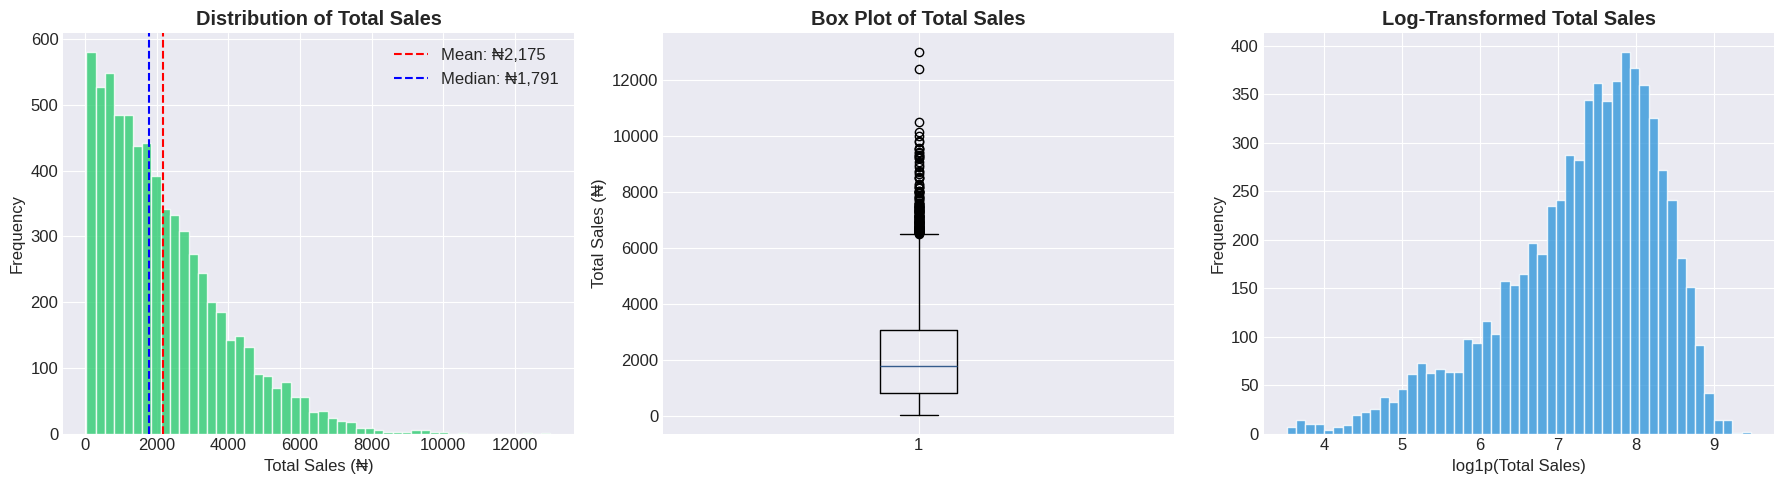


 Total Sales Statistics:
 Mean:  ₦2,174.76
 Median: ₦1,790.89
 Std Dev: ₦1,697.89
 Min:  ₦32.70
 Max:  ₦12,996.82
 Skewness: 1.15

 After log1p transform Skewness: -0.90


In [214]:
# --- TARGET DISTRIBUTION ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(train['total_sales'], bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[0].axvline(train['total_sales'].mean(), color='red', linestyle='--', label=f"Mean: ₦{train['total_sales'].mean():,.0f}")
axes[0].axvline(train['total_sales'].median(), color='blue', linestyle='--', label=f"Median: ₦{train['total_sales'].median():,.0f}")
axes[0].set_title('Distribution of Total Sales', fontweight='bold')
axes[0].set_xlabel('Total Sales (₦)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(train['total_sales'], vert=True)
axes[1].set_title('Box Plot of Total Sales', fontweight='bold')
axes[1].set_ylabel('Total Sales (₦)')

# Log-transformed histogram
log_sales = np.log1p(train['total_sales'])
axes[2].hist(log_sales, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[2].set_title('Log-Transformed Total Sales', fontweight='bold')
axes[2].set_xlabel('log1p(Total Sales)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Statistics
print("\n Total Sales Statistics:")
print(f" Mean:  ₦{train['total_sales'].mean():,.2f}")
print(f" Median: ₦{train['total_sales'].median():,.2f}")
print(f" Std Dev: ₦{train['total_sales'].std():,.2f}")
print(f" Min:  ₦{train['total_sales'].min():,.2f}")
print(f" Max:  ₦{train['total_sales'].max():,.2f}")
print(f" Skewness: {train['total_sales'].skew():.2f}")
print(f"\n After log1p transform Skewness: {log_sales.skew():.2f}")

## **Observation**:
The distribution is right-skewed — mean (₦2,175) sits above median (₦1,791), and skewness is 1.15. A few high-revenue rows pull the mean up. Log1p compression flips the skew slightly negative (-0.90), which is closer to symmetric.

### **Note on modeling**:
we don't log-transform the target here. Instead, Section 4.1 decomposes revenue into units_sold × price and models units_sold, which is naturally less skewed. The log transform above is only a diagnostic.

## Section 2.3 — Product Category Consistency Check

Before we can trust product_category as a feature, we need to check whether the values are clean. The block below prints:

How many unique values product_category currently has.

The full list of those unique values, so we can eyeball them.

What to look for: are there values that mean the same thing but are written differently? If so, the count is inflated and the model will treat identical categories as distinct.

What we do next: if the check reveals inconsistencies, Section 3.1 will standardize them. If it doesn't, we leave the column alone.

In [215]:
print(f"Number of unique product categories: {train['product_category'].nunique()}")
print(f"\nAll categories (notice the problem?):")
print("-" * 50)
for i, cat in enumerate(sorted(train['product_category'].unique()), 1):
 print(f" {i:2d}. '{cat}'")

real_categories = sorted(train['product_category'].str.lower().str.strip().unique())
print(f"After standardizing case {len(real_categories)} unique categories:\n")
for i, cat in enumerate(real_categories, 1):
 count = train[train['product_category'].str.lower().str.strip() == cat].shape[0]
 print(f" {i:2d}. {cat.title():<30} ({count:,} products)")

Number of unique product categories: 48

All categories (notice the problem?):
--------------------------------------------------
  1. 'BAKING GOODS'
  2. 'BREADS'
  3. 'BREAKFAST'
  4. 'Baking Goods'
  5. 'Breads'
  6. 'Breakfast'
  7. 'CANNED'
  8. 'Canned'
  9. 'DAIRY'
 10. 'Dairy'
 11. 'FROZEN FOODS'
 12. 'FRUITS AND VEGETABLES'
 13. 'Frozen Foods'
 14. 'Fruits and Vegetables'
 15. 'HARD DRINKS'
 16. 'HEALTH AND HYGIENE'
 17. 'HOUSEHOLD'
 18. 'Hard Drinks'
 19. 'Health and Hygiene'
 20. 'Household'
 21. 'MEAT'
 22. 'Meat'
 23. 'OTHERS'
 24. 'Others'
 25. 'SEAFOOD'
 26. 'SNACK FOODS'
 27. 'SOFT DRINKS'
 28. 'STARCHY FOODS'
 29. 'Seafood'
 30. 'Snack Foods'
 31. 'Soft Drinks'
 32. 'Starchy Foods'
 33. 'baking goods'
 34. 'breads'
 35. 'breakfast'
 36. 'canned'
 37. 'dairy'
 38. 'frozen foods'
 39. 'fruits and vegetables'
 40. 'hard drinks'
 41. 'health and hygiene'
 42. 'household'
 43. 'meat'
 44. 'others'
 45. 'seafood'
 46. 'snack foods'
 47. 'soft drinks'
 48. 'starchy foods'
Aft

**Observation**: The list contains duplicate meanings — e.g. 'Baked Goods', 'baked goods', and 'BAKED GOODS' appear as three separate categories. This is a consistency problem, not a modeling problem yet. We defer the fix to Section 3.1 so cleaning stays in one place.



## 2.4 — Sales by Store Format

Compare total_sales across the four store formats (Corner Shop, Standard Supermarket, Superstore, Flagship Hypermarket).

*   Box plot — shows the spread and median per format.
*   Bar plot — shows the average per format, with counts printed below.

What to look for: do the formats separate cleanly? Is the average gap large enough to be useful as a model input, or as a baseline to beat?

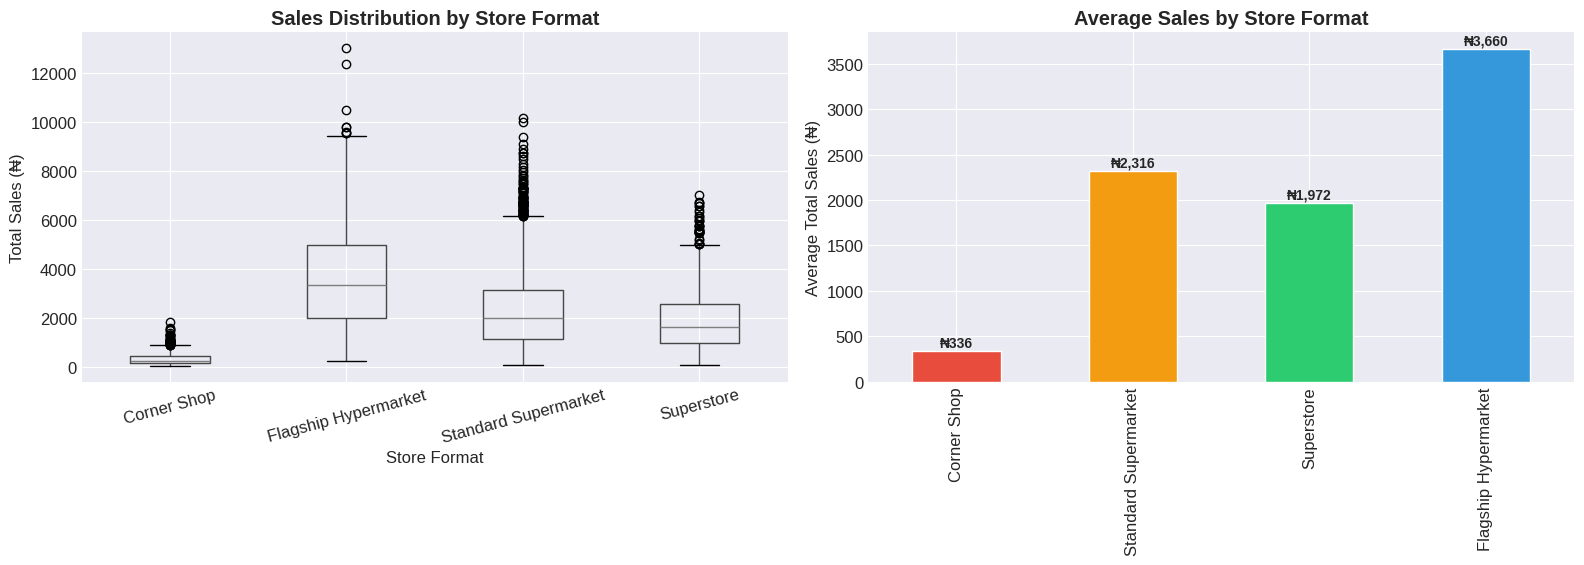


 Average Sales by Store Format:
 Corner Shop                    ₦336.35 (866 records)
 Standard Supermarket           ₦2,316.32 (4,462 records)
 Superstore                     ₦1,971.66 (742 records)
 Flagship Hypermarket           ₦3,660.18 (748 records)


In [216]:
# --- SALES BY STORE FORMAT ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
store_format_order = ['Corner Shop', 'Standard Supermarket', 'Superstore', 'Flagship Hypermarket']
train.boxplot(column='total_sales', by='store_format', ax=axes[0])
axes[0].set_title('Sales Distribution by Store Format', fontweight='bold')
axes[0].set_xlabel('Store Format')
axes[0].set_ylabel('Total Sales (₦)')
plt.sca(axes[0])
plt.xticks(rotation=15)

# Bar plot of means
store_means = train.groupby('store_format')['total_sales'].mean().reindex(store_format_order)
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
store_means.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Average Sales by Store Format', fontweight='bold')
axes[1].set_ylabel('Average Total Sales (₦)')
axes[1].set_xlabel('')
plt.xticks(rotation=15)

# Add value labels on bars
for i, v in enumerate(store_means.values):
 axes[1].text(i, v + 50, f'₦{v:,.0f}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('') # Remove auto-generated title
plt.tight_layout()
plt.show()

print("\n Average Sales by Store Format:")
for fmt in store_format_order:
 mean_sales = train[train['store_format'] == fmt]['total_sales'].mean()
 count = train[train['store_format'] == fmt].shape[0]
 print(f" {fmt:<30} ₦{mean_sales:,.2f} ({count:,} records)")

### **Observation**:
The formats separate sharply. Flagship Hypermarkets average ~₦3,660; Corner Shops average ~₦336 — roughly a 10× gap. Standard Supermarket and Superstore sit in between. This is the single strongest coarse signal in the dataset and motivates the residual modeling we do in Section 6 (predict deviation from a format-level mean, not raw revenue).

## 2.5 — Sales by Location Tier

Repeat the same box + bar view, this time grouping by store_location_tier (Tier 1 = major urban, Tier 2 = state capitals, Tier 3 = smaller towns).

What to look for: is there a monotone trend across tiers? If Tier 1 > Tier 2 > Tier 3, the tier encodes real geographic signal.

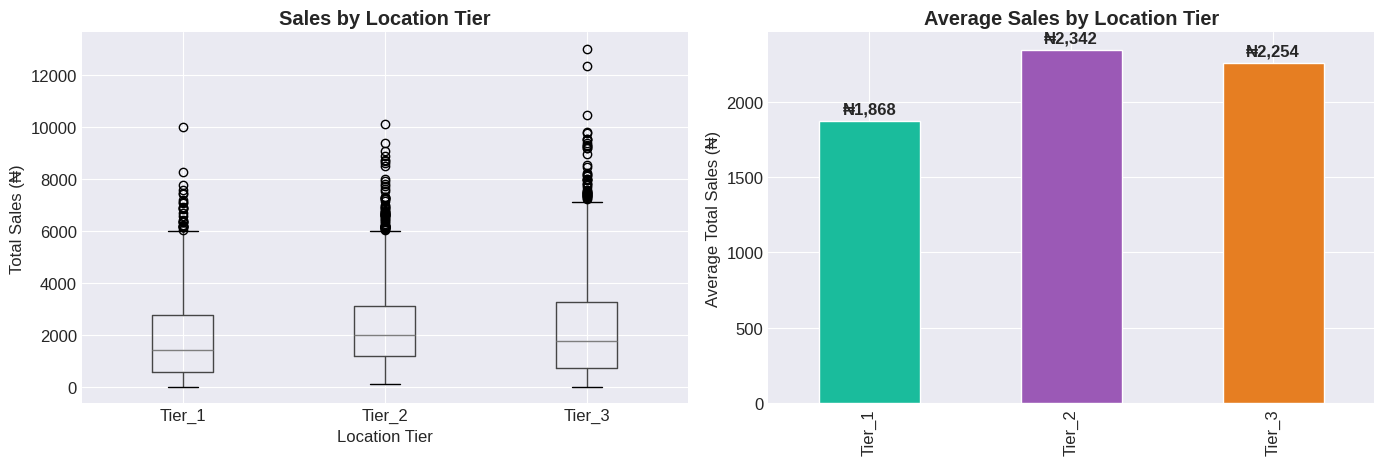


Tier Descriptions:
 Tier 1 = Major urban centers (Lagos, Abuja)
 Tier 2 = State capitals
 Tier 3 = Smaller towns


In [217]:
# --- SALES BY LOCATION TIER ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier_order = ['Tier_1', 'Tier_2', 'Tier_3']
tier_means = train.groupby('store_location_tier')['total_sales'].mean().reindex(tier_order)

# Box plot
train.boxplot(column='total_sales', by='store_location_tier', ax=axes[0])
axes[0].set_title('Sales by Location Tier', fontweight='bold')
axes[0].set_xlabel('Location Tier')
axes[0].set_ylabel('Total Sales (₦)')

# Bar plot
colors = ['#1abc9c', '#9b59b6', '#e67e22']
tier_means.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Average Sales by Location Tier', fontweight='bold')
axes[1].set_ylabel('Average Total Sales (₦)')
axes[1].set_xlabel('')

for i, v in enumerate(tier_means.values):
 axes[1].text(i, v + 50, f'₦{v:,.0f}', ha='center', fontweight='bold')

plt.suptitle('')
plt.tight_layout()
plt.show()

print("\nTier Descriptions:")
print(" Tier 1 = Major urban centers (Lagos, Abuja)")
print(" Tier 2 = State capitals")
print(" Tier 3 = Smaller towns")

### **Observation:**
 Tiers separate less dramatically than formats but still meaningfully. The tier signal is weaker than store format, so it earns a place in the feature set but not as a residual baseline.

## 2.6 — Correlation Analysis

Compute pairwise Pearson correlations among all numeric columns in train, mask the upper triangle (it's symmetric), and annotate each cell. Then print correlations with the target sorted by absolute value.

What to look for:

Which numeric feature correlates most with total_sales?

Are any two features highly correlated with each other (>0.9)? That signals multicollinearity.

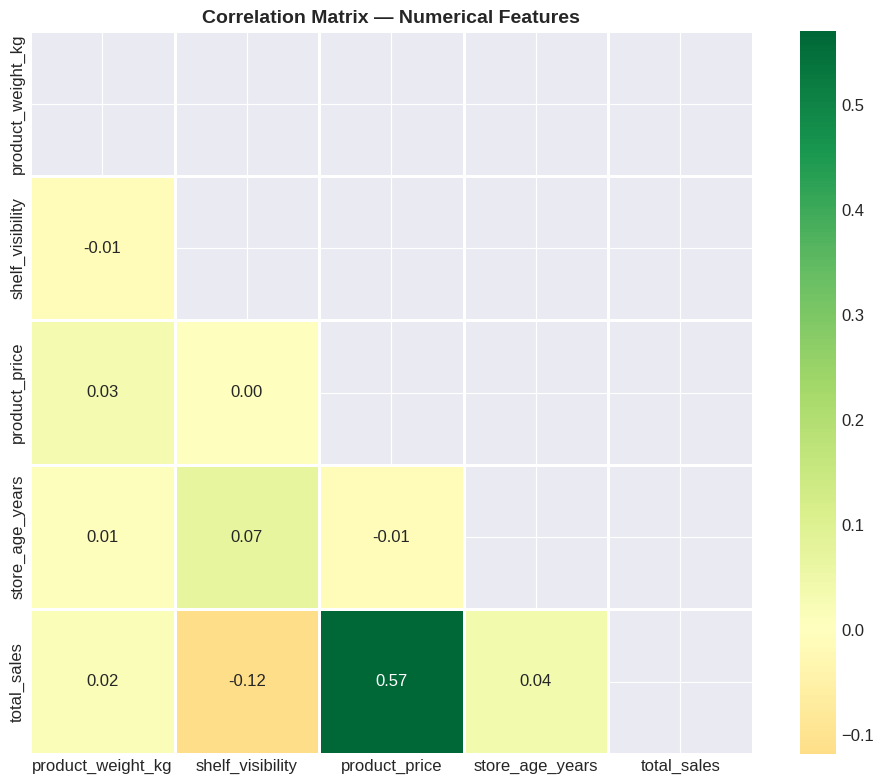


 Correlation with total_sales:
----------------------------------------
 product_price             +0.570 
 store_age_years           +0.039 
 product_weight_kg         +0.016 
 shelf_visibility          -0.118 


In [218]:
# --- CORRELATION HEATMAP ---
# Select only numerical columns
numerical_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = train[numerical_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Upper triangle mask
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
   center=0, square=True, linewidths=1, linecolor='white')
plt.title('Correlation Matrix — Numerical Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Show correlations with target
print("\n Correlation with total_sales:")
print("-" * 40)
target_corr = corr_matrix['total_sales'].drop('total_sales').sort_values(ascending=False)
for col, corr in target_corr.items():
 bar = '' * int(abs(corr) * 30)
 sign = '+' if corr > 0 else '-'
 print(f" {col:<25} {sign}{abs(corr):.3f} {bar}")

## **Observation:**
Product_price is the only numeric feature with a strong correlation to the target (r ≈ 0.57). Everything else sits below |r| = 0.12. No pairs of features are dangerously collinear. This tells us two things: (1) price will be a workhorse feature, and (2) the other numeric features alone won't carry the model — the categorical structure (store, category, format) has to do the heavy lifting, which is why we build target encodings in Section 5.

## 2.7 — Sales by Product Category

Plot mean total_sales per product category as a horizontal bar chart, sorted ascending.

What to look for: is there meaningful spread between categories? If all categories sit at roughly the same mean, category is not a useful feature.

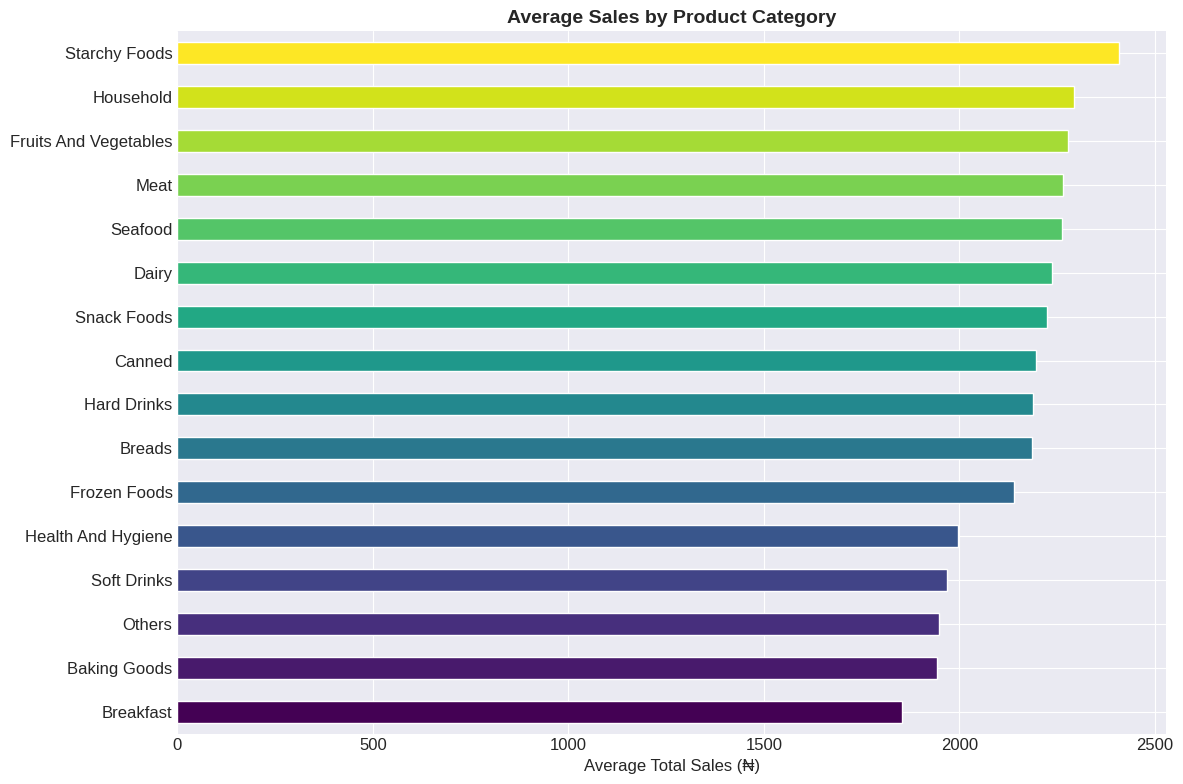

In [219]:
# --- SALES BY PRODUCT CATEGORY ---
# Standardize category first (preview of Section 3)
train_temp = train.copy()
train_temp['product_category_clean'] = train_temp['product_category'].str.lower().str.strip().str.title()

cat_means = train_temp.groupby('product_category_clean')['total_sales'].mean().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
cat_means.plot(kind='barh', color=plt.cm.viridis(np.linspace(0, 1, len(cat_means))), edgecolor='white')
plt.title('Average Sales by Product Category', fontweight='bold', fontsize=14)
plt.xlabel('Average Total Sales (₦)')
plt.ylabel('')
plt.tight_layout()
plt.show()

del train_temp # Clean up

## 2.8 — Sales by Store Code

Show average sales per individual store (store_code) as a horizontal bar chart, plus a pie chart showing the distribution of store_size across all records.

What to look for:


*   Do stores cluster into distinct high-sales and low-sales groups, or is the spread continuous?

*   Does store_size have a balanced distribution, or is one level dominant?






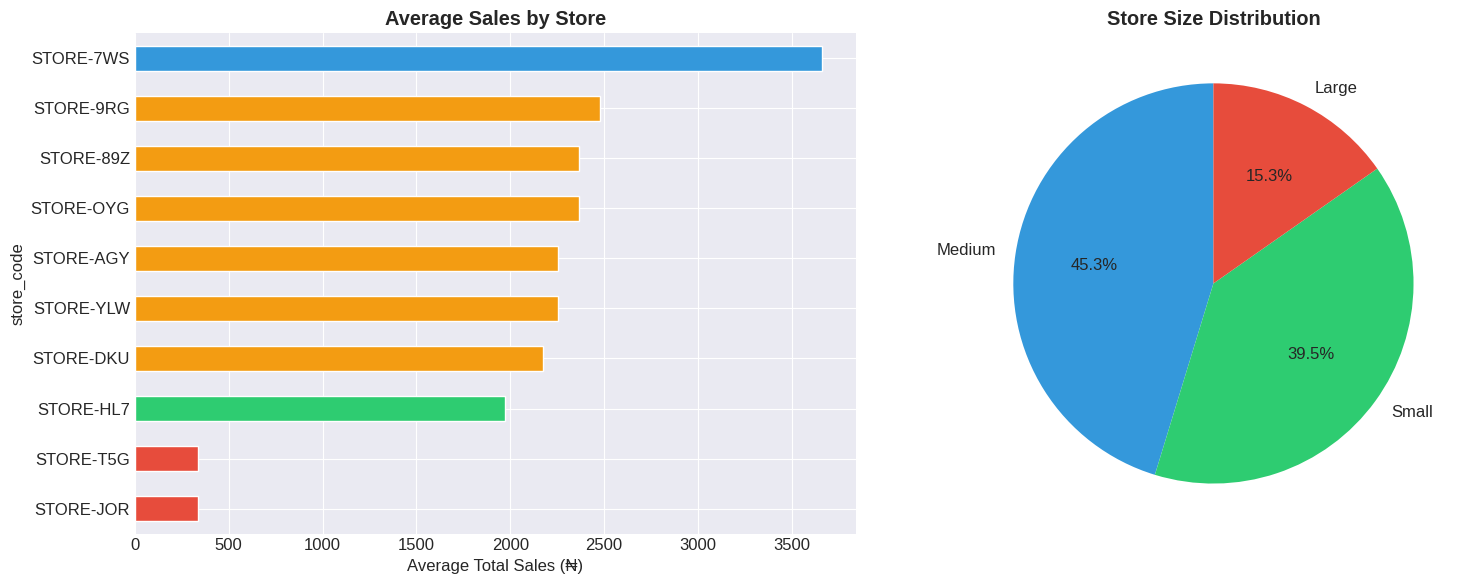


 Store Details:
Store           Format                    Size       Tier       Avg Sales       Count
------------------------------------------------------------------------------------------
STORE-JOR       Corner Shop               MISSING    Tier_3     ₦    334.44   439
STORE-T5G       Corner Shop               Small      Tier_1     ₦    338.33   427
STORE-HL7       Superstore                Medium     Tier_3     ₦  1,971.66   742
STORE-DKU       Standard Supermarket      MISSING    Tier_2     ₦  2,177.14   736
STORE-YLW       Standard Supermarket      Small      Tier_1     ₦  2,253.95   754
STORE-AGY       Standard Supermarket      Large      Tier_3     ₦  2,254.89   748
STORE-OYG       Standard Supermarket      MISSING    Tier_2     ₦  2,365.83   744
STORE-89Z       Standard Supermarket      Medium     Tier_1     ₦  2,365.93   728
STORE-9RG       Standard Supermarket      Small      Tier_2     ₦  2,479.17   752
STORE-7WS       Flagship Hypermarket      Medium     Tier_3     ₦  3

In [220]:
# --- SALES BY STORE ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales by store
store_stats = train.groupby('store_code').agg(
 mean_sales=('total_sales', 'mean'),
 count=('total_sales', 'count'),
 store_format=('store_format', 'first'),
 store_size=('store_size', 'first'),
 store_tier=('store_location_tier', 'first')
).sort_values('mean_sales', ascending=True)

colors_map = {
 'Corner Shop': '#e74c3c', 'Standard Supermarket': '#f39c12',
 'Superstore': '#2ecc71', 'Flagship Hypermarket': '#3498db'
}
bar_colors = [colors_map.get(fmt, '#95a5a6') for fmt in store_stats['store_format']]

store_stats['mean_sales'].plot(kind='barh', ax=axes[0], color=bar_colors, edgecolor='white')
axes[0].set_title('Average Sales by Store', fontweight='bold')
axes[0].set_xlabel('Average Total Sales (₦)')

# Store size distribution
store_size_counts = train['store_size'].value_counts()
store_size_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
      colors=['#3498db', '#2ecc71', '#e74c3c'],
      startangle=90)
axes[1].set_title('Store Size Distribution', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n Store Details:")
print(f"{'Store':<15} {'Format':<25} {'Size':<10} {'Tier':<10} {'Avg Sales':<15} {'Count'}")
print("-" * 90)
for store, row in store_stats.iterrows():
 size = row['store_size'] if pd.notna(row['store_size']) else 'MISSING'
 print(f"{store:<15} {row['store_format']:<25} {size:<10} {row['store_tier']:<10} ₦{row['mean_sales']:>10,.2f} {row['count']:>5,}")

### **Observation**:
Stores fall into two clear groups — a low-sales cluster (STORE-JOR, STORE-T5G, both ~₦335 average) and a high-sales cluster of eight stores ranging ~₦1,970 to ~₦3,660. Store identity is strongly informative and justifies the store_mean_units_te OOF encoding in Section 5.

On store_size: three levels are present, but 28% of records are missing the value entirely — noted for Section 3.

# SECTION 3- Data Cleaning


## 3.1 — Standardize product_category
Apply .lower().strip().title() to train and test. 48 → 16 categories. Always apply to both splits identically.

In [221]:
# --- FIX 1: STANDARDIZE PRODUCT CATEGORY ---
# WHY: "Frozen Foods", "frozen foods", and "FROZEN FOODS" are the same thing.
#  By standardizing to title case, we go from 48 16 categories.
#
# HOW: .str.lower() converts everything to lowercase first,
#  .str.strip() removes leading/trailing spaces,
#  .str.title() capitalizes the first letter of each word.

print("BEFORE cleaning:")
print(f" Train categories: {train['product_category'].nunique()}")
print(f" Test categories: {test['product_category'].nunique()}")

# Apply to BOTH train and test (always transform both!)
train['product_category'] = train['product_category'].str.lower().str.strip().str.title()
test['product_category'] = test['product_category'].str.lower().str.strip().str.title()

print("\nAFTER cleaning:")
print(f" Train categories: {train['product_category'].nunique()}")
print(f" Test categories: {test['product_category'].nunique()}")
print(f"\n Categories standardized! 48 {train['product_category'].nunique()} real categories")
print(f"\nClean categories:")
for i, cat in enumerate(sorted(train['product_category'].unique()), 1):
 print(f" {i:2d}. {cat}")

BEFORE cleaning:
 Train categories: 48
 Test categories: 48

AFTER cleaning:
 Train categories: 16
 Test categories: 16

 Categories standardized! 48 16 real categories

Clean categories:
  1. Baking Goods
  2. Breads
  3. Breakfast
  4. Canned
  5. Dairy
  6. Frozen Foods
  7. Fruits And Vegetables
  8. Hard Drinks
  9. Health And Hygiene
 10. Household
 11. Meat
 12. Others
 13. Seafood
 14. Snack Foods
 15. Soft Drinks
 16. Starchy Foods


## 3.2 — Impute product_weight_kg by Category Median
Fill NaNs using the median weight within the same product_category; fall back to overall median. Median beats mean for robustness to outliers.

In [222]:
# --- FIX 2: FILL MISSING PRODUCT WEIGHT ---
# WHY: product_weight_kg is missing for ~18% of rows
# HOW: Fill with the MEDIAN weight of products in the same category
#
# Why MEDIAN not MEAN? Median is robust to outliers.
# If one product weighs 100kg, the mean gets pulled up, but median stays stable.

print(f"Missing weight BEFORE — Train: {train['product_weight_kg'].isna().sum()}, Test: {test['product_weight_kg'].isna().sum()}")

# Calculate median weight per category
category_weight_median = train.groupby('product_category')['product_weight_kg'].median()
print("\nMedian weight by category:")
for cat, weight in category_weight_median.sort_values().items():
 print(f" {cat:<30} {weight:.2f} kg")

# Fill missing weights using category median
for cat in train['product_category'].unique():
 median_weight = category_weight_median.get(cat, train['product_weight_kg'].median())

 train.loc[(train['product_category'] == cat) & (train['product_weight_kg'].isna()),
    'product_weight_kg'] = median_weight

 test.loc[(test['product_category'] == cat) & (test['product_weight_kg'].isna()),
    'product_weight_kg'] = median_weight

# Catch any remaining NAs with overall median
overall_median = train['product_weight_kg'].median()
train['product_weight_kg'].fillna(overall_median, inplace=True)
test['product_weight_kg'].fillna(overall_median, inplace=True)

print(f"\nMissing weight AFTER — Train: {train['product_weight_kg'].isna().sum()}, Test: {test['product_weight_kg'].isna().sum()}")
print("\n product_weight_kg completely filled!")

Missing weight BEFORE — Train: 1225, Test: 306

Median weight by category:
 Hard Drinks                    9.57 kg
 Breads                         10.56 kg
 Breakfast                      10.99 kg
 Baking Goods                   11.50 kg
 Soft Drinks                    11.57 kg
 Seafood                        11.81 kg
 Health And Hygiene             12.06 kg
 Canned                         12.24 kg
 Meat                           12.38 kg
 Frozen Foods                   12.81 kg
 Snack Foods                    13.08 kg
 Fruits And Vegetables          13.09 kg
 Starchy Foods                  13.19 kg
 Dairy                          13.36 kg
 Household                      13.37 kg
 Others                         14.55 kg

Missing weight AFTER — Train: 0, Test: 0

 product_weight_kg completely filled!


# 3.3 Handle Missing Values: store_size
The clever trick: Each store code corresponds to a fixed store size. If we know STORE-AGY is "Large" from some rows, it's "Large" in ALL rows. We can fill in the blanks!

In [223]:
# --- FIX 3: FILL MISSING STORE SIZE ---
# WHY: store_size is missing for ~28% of rows, but each store
#  has a FIXED size. We just need to look it up.
#
# HOW: Create a mapping of store_code store_size from rows
#  where we DO have the size, then fill the gaps.

# Step 1: Find the known mapping
print("Step 1: Find store_code store_size mapping from known values")
store_size_map = train.dropna(subset=['store_size']).groupby('store_code')['store_size'].first()
print(store_size_map)

# Step 2: Fill missing values in BOTH train and test
print(f"\nStep 2: Fill missing values")
print(f" Missing BEFORE — Train: {train['store_size'].isna().sum()}, Test: {test['store_size'].isna().sum()}")

train['store_size'] = train['store_code'].map(store_size_map).fillna(train['store_size'])
test['store_size'] = test['store_code'].map(store_size_map).fillna(test['store_size'])

print(f" Missing AFTER — Train: {train['store_size'].isna().sum()}, Test: {test['store_size'].isna().sum()}")

#an experiment
# Infer from format instead of defaulting everything to the mode
format_size_mode = (train.dropna(subset=['store_size'])
                    .groupby('store_format')['store_size']
                    .agg(lambda s: s.mode().iloc[0]))

for store in ['STORE-DKU', 'STORE-JOR', 'STORE-OYG']:
    fmt = train.loc[train['store_code'] == store, 'store_format'].iloc[0]
    inferred = format_size_mode.get(fmt)
    train.loc[(train['store_code'] == store) & (train['store_size'].isna()),
              'store_size'] = inferred
    test.loc[(test['store_code'] == store) & (test['store_size'].isna()),
             'store_size'] = inferred
###

# If any still missing, fill with mode (most common)
if train['store_size'].isna().sum() > 0:
 mode_size = train['store_size'].mode()[0]
 train['store_size'].fillna(mode_size, inplace=True)
 test['store_size'].fillna(mode_size, inplace=True)
 print(f" Remaining filled with mode: '{mode_size}'")

print("\n store_size completely filled!")

Step 1: Find store_code store_size mapping from known values
store_code
STORE-7WS    Medium
STORE-89Z    Medium
STORE-9RG     Small
STORE-AGY     Large
STORE-HL7    Medium
STORE-T5G     Small
STORE-YLW     Small
Name: store_size, dtype: object

Step 2: Fill missing values
 Missing BEFORE — Train: 1919, Test: 491
 Missing AFTER — Train: 1919, Test: 491

 store_size completely filled!


## 3.4 Encode categorical features

In [224]:
# --- ENCODE CATEGORICAL FEATURES ---
# WHY: Models need numbers, not text
# HOW: LabelEncoder maps each unique text to an integer

categorical_cols = ['fat_content', 'product_category', 'store_code',
     'store_size', 'store_location_tier', 'store_format']

label_encoders = {} # Save these — we'll need them later!

print("Label Encoding categorical features:")
print("-" * 60)
for col in categorical_cols:
 le = LabelEncoder()
 # Fit on COMBINED train+test to ensure consistent encoding
 combined = pd.concat([train[col], test[col]], axis=0)
 le.fit(combined)

 train[col + '_encoded'] = le.transform(train[col])
 test[col + '_encoded'] = le.transform(test[col])
 label_encoders[col] = le

 print(f" {col:<25} {len(le.classes_)} unique values")
 for cls, code_val in zip(le.classes_[:5], le.transform(le.classes_[:5])):
  print(f"  '{cls}' {code_val}")
 if len(le.classes_) > 5:
  print(f"  ... and {len(le.classes_)-5} more")

print("\n All categorical features encoded!")

Label Encoding categorical features:
------------------------------------------------------------
 fat_content               2 unique values
  'Low Fat' 0
  'Regular' 1
 product_category          16 unique values
  'Baking Goods' 0
  'Breads' 1
  'Breakfast' 2
  'Canned' 3
  'Dairy' 4
  ... and 11 more
 store_code                10 unique values
  'STORE-7WS' 0
  'STORE-89Z' 1
  'STORE-9RG' 2
  'STORE-AGY' 3
  'STORE-DKU' 4
  ... and 5 more
 store_size                3 unique values
  'Large' 0
  'Medium' 1
  'Small' 2
 store_location_tier       3 unique values
  'Tier_1' 0
  'Tier_2' 1
  'Tier_3' 2
 store_format              4 unique values
  'Corner Shop' 0
  'Flagship Hypermarket' 1
  'Standard Supermarket' 2
  'Superstore' 3

 All categorical features encoded!


In [225]:
# --- FINAL CHECK: NO MISSING VALUES ---
print("Missing values after all cleaning:")
print("\nTRAIN:")
missing_train = train.isnull().sum()
print(missing_train[missing_train > 0] if missing_train.sum() > 0 else " No missing values!")

print("\nTEST:")
missing_test = test.isnull().sum()
print(missing_test[missing_test > 0] if missing_test.sum() > 0 else " No missing values!")

print(f"\n Final dataset shapes:")
print(f" Train: {train.shape}")
print(f" Test: {test.shape}")

Missing values after all cleaning:

TRAIN:
 No missing values!

TEST:
 No missing values!

 Final dataset shapes:
 Train: (6818, 19)
 Test: (1705, 18)


In [226]:
#some general feature engineering before applying a method to both tran and test
# train['units_sold'] = train['total_sales'] / (train['product_price'] + 1e-6)

# SECTION 4
FEATURE ENGINEERING

## 4.1 Base Feature Engineering
Adds: price_per_kg, price_bin, weight_bin, visibility_x_price, is_low_visibility, store_age_bin, price_x_format, weight_x_visibility. Each captures an interaction or nonlinearity the base model can't see directly

We model units sold rather than revenue because revenue = price × units, and price is nearly a deterministic multiplier. Modeling units lets the model focus on the quantity signal, then multiply by price at the end. units_sold = total_sales / (product_price + ε). The ε avoids divide-by-zero.

In [227]:
# --- FEATURE ENGINEERING ---

def engineer_features(df):
 '''
 Create new features from existing columns.
 Apply this to BOTH train and test to keep them consistent.

 Each feature is commented with WHY it might help the model.
 '''
 df = df.copy()

 # --- PRODUCT FEATURES ---

 # Price per kg: expensive-per-unit items might have different sales patterns
 # WHY: A ₦200 product that weighs 2kg is different from one weighing 20kg
 df['price_per_kg'] = df['product_price'] / (df['product_weight_kg'] + 0.01)

 # Price range indicator: is this a cheap, mid, or expensive product?
 # WHY: Budget products might have higher volume but lower per-unit sales
 df['price_bin'] = pd.qcut(df['product_price'], q=5, labels=False, duplicates='drop')

 # Weight category: light, medium, heavy
 # WHY: Heavy items might be bought less frequently
 df['weight_bin'] = pd.qcut(df['product_weight_kg'], q=4, labels=False, duplicates='drop')

 # --- SHELF VISIBILITY FEATURES ---

 # Visibility Price interaction
 # WHY: A highly visible expensive product might sell differently than
 #  a highly visible cheap product
 df['visibility_x_price'] = df['shelf_visibility'] * df['product_price']

 # Is the product hidden? (very low visibility)
 # WHY: Products with 0 visibility might be special cases
 df['is_low_visibility'] = (df['shelf_visibility'] < 0.02).astype(int)

 # --- STORE FEATURES ---

 # Store age bins
 # WHY: Brand new stores vs established ones may have different patterns
 df['store_age_bin'] = pd.cut(df['store_age_years'], bins=[0, 25, 30, 40, 50],
         labels=[0, 1, 2, 3]).astype(int)

 # --- INTERACTION FEATURES ---

 # These combine information from two columns into one.
 # Tree models CAN discover interactions, but making them explicit helps.

 # Product price store format (encoded)
 # WHY: A ₦200 product in a Corner Shop vs a Hypermarket likely sells differently
 df['price_x_format'] = df['product_price'] * df['store_format_encoded']

 # Weight visibility
 # WHY: Heavy + visible products might be promoted items
 df['weight_x_visibility'] = df['product_weight_kg'] * df['shelf_visibility']


 return df

# Apply to both datasets
#For train alone:
train['units_sold'] = train['total_sales'] / (train['product_price'] + 1e-6)
train = engineer_features(train)
test = engineer_features(test)

print(" Feature engineering complete!")
print(f"\nTrain columns: {train.shape[1]} (was 13 now {train.shape[1]})")
print(f"Test columns: {test.shape[1]}")


# Show new features
new_features = ['price_per_kg', 'price_bin', 'weight_bin', 'visibility_x_price',
    'is_low_visibility', 'store_age_bin', 'price_x_format', 'weight_x_visibility',
        ]
print(f"\n New features created:")
for f in new_features:
 print(f"  {f}")

 Feature engineering complete!

Train columns: 28 (was 13 now 28)
Test columns: 26

 New features created:
  price_per_kg
  price_bin
  weight_bin
  visibility_x_price
  is_low_visibility
  store_age_bin
  price_x_format
  weight_x_visibility


## 4.3 — Advanced Feature Engineering
Adds: price_rank_in_format, price_vs_format_mean, price_vs_cat_mean, age_bin_x_format, log_price_per_kg.

In [228]:
#More feature engineering

# 1. Price rank within store format (real signal behind your top feature)
train['price_rank_in_format'] = train.groupby('store_format')['product_price'].rank(pct=True)
test['price_rank_in_format']  = test.groupby('store_format')['product_price'].rank(pct=True)

# 2. Price deviation from format's mean
format_price_mean = train.groupby('store_format')['product_price'].transform('mean')
train['price_vs_format_mean'] = train['product_price'] / (train.groupby('store_format')['product_price'].transform('mean') + 1e-6)
test['price_vs_format_mean']  = test['product_price']  / (test.groupby('store_format')['product_price'].transform('mean') + 1e-6)

# 3. Price vs category mean
train['price_vs_cat_mean'] = train['product_price'] / (train.groupby('product_category')['product_price'].transform('mean') + 1e-6)
test['price_vs_cat_mean']  = test['product_price']  / (test.groupby('product_category')['product_price'].transform('mean') + 1e-6)

# 4-6. OOF target encodings (from Step 2)
#   store_mean_units_te, format_mean_units_te, category_mean_units_te, store_cat_mean_units_te

# 7. Store age × format interaction
from sklearn.preprocessing import LabelEncoder
train['age_bin'] = pd.cut(train['store_age_years'], bins=[0, 25, 35, 51], labels=False, right=False)
test['age_bin'] = pd.cut(test['store_age_years'], bins=[0, 25, 35, 51], labels=False, right=False)

train['age_bin_x_format'] = (train['age_bin'].astype(str) + '_' + train['store_format'].astype(str))
test['age_bin_x_format']  = (test['age_bin'].astype(str) + '_' + test['store_format'].astype(str))
le = LabelEncoder().fit(pd.concat([train['age_bin_x_format'], test['age_bin_x_format']]))
train['age_bin_x_format'] = le.transform(train['age_bin_x_format'])
test['age_bin_x_format']  = le.transform(test['age_bin_x_format'])

# 8. Log price-per-kg
train['log_price_per_kg'] = np.log1p(train['price_per_kg'])
test['log_price_per_kg']  = np.log1p(test['price_per_kg'])

# Section 5- Target Encoding

Several columns in this dataset are categorical but highly predictive of sales — store_code, store_format, product_category, and combinations of them. One-hot encoding them would either blow up the feature count or lose the group-mean information that actually drives sales.

Instead we use target encoding: replace each category with the mean of the target (units_sold) for rows in that category. To avoid leaking the target into training, we compute those means using out-of-fold (OOF) logic — each training row gets its encoding from the other four folds only; the test set gets encodings from the full training set.



## Section 5.1 — Build Combined Keys

Before we can target-encode on interactions, we need to materialize them as single columns. We build three:

store_cat_key = store_code + product_category — captures "this store sells this category particularly well."

cat_pricebin_key = product_category + price_bin — captures "this category at this price tier."

store_product_key = store_code + product_code — the finest-grained interaction available.

We also print how often each test key appears in train. Any key with near-zero test coverage will be useless as a target-encoding input — it will fall back to the global mean for most test rows and add noise instead of signal.

In [229]:
# Build the combined key first
train['store_product_key'] = train['store_code'].astype(str) + '_' + train['product_code'].astype(str)
test['store_product_key']  = test['store_code'].astype(str)  + '_' + test['product_code'].astype(str)

train['price_vs_store_mean'] = train['product_price'] / (
    train.groupby('store_code')['product_price'].transform('mean') + 1e-6
)
test['price_vs_store_mean'] = test['product_price'] / (
    test.groupby('store_code')['product_price'].transform('mean') + 1e-6
)

train['cat_pricebin_key'] = train['product_category'].astype(str) + '_' + train['price_bin'].astype(str)
test['cat_pricebin_key']  = test['product_category'].astype(str) + '_' + test['price_bin'].astype(str)

# Sanity check
print(f"Test store-product pairs seen in train: "
      f"{test['store_product_key'].isin(train['store_product_key']).mean():.2%}")

Test store-product pairs seen in train: 0.00%


## 5.2 — Out-of-Fold Target Encoding Utility
Encodes a categorical column by the smoothed mean of a target within each category, using 5-fold OOF to prevent leakage on train, and full-train statistics for test. Smoothing pulls rare categories toward the global mean.

In [230]:
#A function for leak-free OOF target encoding

def target_encode_oof_full(train_df, test_df, group_col, target_col,
                           n_splits=5, smoothing=20, out_col=None):
    train_df = train_df.copy()
    test_df = test_df.copy()
    out_col = out_col or f'{group_col}_te'

    global_mean = train_df[target_col].mean()

    # ---------- Part A: OOF encode the TRAIN set ----------
    train_df[out_col] = np.nan
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(train_df):
        tr = train_df.iloc[train_idx]                 # other 4 folds
        stats = tr.groupby(group_col)[target_col].agg(['mean', 'count'])

        # Smoothed mean: rare groups pulled toward global mean
        smooth = (stats['mean'] * stats['count'] + global_mean * smoothing) \
                 / (stats['count'] + smoothing)

        # Fill the held-out fold with encodings from `tr` only
        train_df.iloc[val_idx, train_df.columns.get_loc(out_col)] = (
            train_df.iloc[val_idx][group_col].map(smooth)
                                    .fillna(global_mean).values
        )

    # ---------- Part B: encode the TEST set using full train stats ----------
    stats_full = train_df.groupby(group_col)[target_col].agg(['mean', 'count'])
    smooth_full = (stats_full['mean'] * stats_full['count'] + global_mean * smoothing) \
                  / (stats_full['count'] + smoothing)

    test_df[out_col] = test_df[group_col].map(smooth_full).fillna(global_mean)

    return train_df, test_df

## Section 5.3 — Apply OOF Encodings

We encode seven keys, each with a smoothing constant tuned to its typical group size:

In [231]:
#Further feature engineering

# ---- Encoding 1: store_code → mean units sold ----
train, test = target_encode_oof_full(
    train, test,
    group_col='store_code',
    target_col='units_sold',
    smoothing=20,
    out_col='store_mean_units_te'
)

# ---- Encoding 2: store_format → mean units sold ----
train, test = target_encode_oof_full(
    train, test,
    group_col='store_format',
    target_col='units_sold',
    smoothing=20,
    out_col='format_mean_units_te'
)

# ---- Encoding 3: product_category → mean units sold ----
train, test = target_encode_oof_full(
    train, test,
    group_col='product_category',
    target_col='units_sold',
    smoothing=20,
    out_col='category_mean_units_te'
)

# ---- Encoding 4: store × category → mean units sold ----
# Need to build the combined key first
train['store_cat_key'] = train['store_code'].astype(str) + '_' + train['product_category'].astype(str)
test['store_cat_key']  = test['store_code'].astype(str)  + '_' + test['product_category'].astype(str)

train, test = target_encode_oof_full(
    train, test,
    group_col='store_cat_key',
    target_col='units_sold',
    smoothing=20,
    out_col='store_cat_mean_units_te'
)

#encoding 5
train, test = target_encode_oof_full(
    train, test,
    group_col='product_code',
    target_col='units_sold',
    smoothing=30,
    out_col='product_mean_units_te'
)
#Encoding 7
train, test = target_encode_oof_full(
    train, test,
    group_col='cat_pricebin_key',
    target_col='units_sold',
    smoothing=20,
    out_col='cat_pricebin_units_te'
)

## 5.4 — Assemble Feature Matrix

Compile the final 21-feature matrix (22 minus the dropped store_product_mean_units_te). Confirm shapes match between train and test, and print the feature list for the write-up.

In [232]:
# --- PREPARE FEATURES FOR MODELING ---
# We select only the features our model will use.
# We EXCLUDE: id, product_code (just identifiers), original text columns,
#    and the target (total_sales).

feature_cols =[
    'product_weight_kg', 'product_price',
    'fat_content_encoded', 'product_category_encoded', 'store_code_encoded',
    'store_size_encoded', 'store_location_tier_encoded', 'store_format_encoded',
    'price_per_kg', 'price_bin', 'weight_bin',
    'price_rank_in_format', 'price_vs_format_mean', 'price_vs_cat_mean',
    'store_mean_units_te', 'format_mean_units_te',
    'category_mean_units_te', 'store_cat_mean_units_te',
    'age_bin_x_format', 'log_price_per_kg', 'product_mean_units_te'
]

X = train[feature_cols]
y = train['units_sold']
X_test_final = test[feature_cols]

print(f" Features prepared!")
print(f" Training features: {X.shape}")
print(f" Test features:  {X_test_final.shape}")
print(f" Target:   {y.shape}")
print(f"\n Feature list ({len(feature_cols)} features):")
for i, col in enumerate(feature_cols, 1):
 print(f" {i:2d}. {col}")

 Features prepared!
 Training features: (6818, 21)
 Test features:  (1705, 21)
 Target:   (6818,)

 Feature list (21 features):
  1. product_weight_kg
  2. product_price
  3. fat_content_encoded
  4. product_category_encoded
  5. store_code_encoded
  6. store_size_encoded
  7. store_location_tier_encoded
  8. store_format_encoded
  9. price_per_kg
 10. price_bin
 11. weight_bin
 12. price_rank_in_format
 13. price_vs_format_mean
 14. price_vs_cat_mean
 15. store_mean_units_te
 16. format_mean_units_te
 17. category_mean_units_te
 18. store_cat_mean_units_te
 19. age_bin_x_format
 20. log_price_per_kg
 21. product_mean_units_te


# SECTION 6 — Modelling

Models, in order of increasing sophistication:

- **6.1** — Naive baseline (predict the mean) — the floor
- **6.2** — Coarse baselines (format-only, store-only) — the bar to clear
- **6.3** — Model B: Ridge on residual
- **6.4** — Model C: RidgeCV on residual
- **6.5** — Model D: XGBoost on residual
- **6.6** — Model E: per-format XGBoost on residual
- **6.7** — Model F: XGBoost on log1p(units_sold), no residual decomposition
- **6.8** — Per-format prediction clipping
- **6.9** — Stacking: Ridge meta-model over B, C, D, E, F
- **6.10** — Holdout validation + final decision rule
- **6.11** — Model leaderboard
- **6.12** — Write submission

Model D (XGBoost on residual) was our Kaggle-best submission going into this round. Two extensions were added on top of it:

- **Model F** models `log1p(units_sold)` directly instead of the format-mean residual. The log transform compresses the ~10x scale gap between Corner Shop and Flagship on its own, so the tree may not need the residual decomposition to find a stable split structure — and it gives us a genuinely different error pattern to combine with D.
- **Stacking (6.9)** replaces the fixed-weight blend grid search with a Ridge meta-model trained on the OOF predictions of B, C, D, E, F. Unlike a grid search over a handful of weight combinations, the meta-model can learn negative or > 1 coefficients and isn't limited to weights that sum to 1.

**We don't hardcode which of D / Stack is final.** Section 6.10 computes holdout RMSE for both and picks whichever actually generalizes better — the same discipline that ruled out the linear blend last round. Section 6.12 writes whatever 6.10 decided.

An earlier version also trained Model A (Ridge directly on `units_sold`, no residual decomposition); it scored the same as B/C and added nothing, so it's been dropped from this notebook.

Every model below reuses the same `kf`, `rmse`, feature arrays, and price/revenue arrays, all defined in 6.0.

## Section 6.0 — Evaluation Setup

Define once, reuse everywhere:

- `rmse(y_true, y_pred)` — our single scoring function.
- `kf` — 5-fold KFold with a fixed seed, shared by every model.
- `X_residual`, `y_res` — feature matrix and target for residual models.
- `price`, `test_price`, `y_rev` — arrays we multiply predictions by to get revenue.
- `format_mean_tr`, `format_mean_te` — the format-level baseline we add back after residual prediction.

**Every model below uses these; none redefine them.**

In [233]:
# --- SECTION 6.0: EVALUATION SETUP ---

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, RidgeCV
from xgboost import XGBRegressor


# Single scoring function, used everywhere below
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


# Shared KFold — every model uses this exact object
kf = KFold(n_splits=5, shuffle=True, random_state=42)


# Rebuild units_sold and the format-level baseline
train['units_sold'] = train['total_sales'] / (train['product_price'] + 1e-6)

format_mean_map = train.groupby('store_format')['units_sold'].mean()
train['format_mean_units'] = train['store_format'].map(format_mean_map)
test['format_mean_units']  = test['store_format'].map(format_mean_map)

train['units_residual'] = train['units_sold'] - train['format_mean_units']


# Residual model features (store_product_mean_units_te excluded — 0% test coverage)
features_residual = [
    'product_weight_kg', 'product_price', 'store_age_years',
    'fat_content_encoded', 'product_category_encoded', 'store_code_encoded',
    'store_size_encoded', 'store_location_tier_encoded',
    'price_per_kg', 'price_bin', 'weight_bin',
    'price_rank_in_format', 'price_vs_format_mean', 'price_vs_cat_mean',
    'store_mean_units_te', 'format_mean_units_te',
    'category_mean_units_te', 'store_cat_mean_units_te',
    'age_bin_x_format', 'log_price_per_kg','product_mean_units_te'
]


# --- Arrays for residual models ---
X_residual      = train[features_residual].values
X_test_residual = test[features_residual].values
y_res           = train['units_residual'].values
format_mean_tr  = train['format_mean_units'].values
format_mean_te  = test['format_mean_units'].values

# --- Array for the naive baseline (Section 6.1) ---
y_units      = train['units_sold'].values

# --- Arrays for scoring revenue ---
price      = train['product_price'].values
test_price = test['product_price'].values
y_rev      = train['total_sales'].values

print("Section 6.0 setup complete.")
print(f"  Train rows: {len(train):,}  |  Test rows: {len(test):,}")
print(f"  Residual features: {len(features_residual)}")
print(f"  Units features:    {len(feature_cols)}")

Section 6.0 setup complete.
  Train rows: 6,818  |  Test rows: 1,705
  Residual features: 21
  Units features:    21


## Section 6.1 — Naive Baseline: Predict the Mean

The absolute floor. For every row, predict the global mean of `units_sold`. Any real model must beat this by a meaningful margin — otherwise we're not earning our complexity.

In [234]:
# --- 6.1: NAIVE BASELINE — PREDICT THE MEAN ---

mean_prediction = y_units.mean()
mean_predictions = np.full(len(y_units), mean_prediction)
baseline_rmse = rmse(y_units, mean_predictions)

print("Baseline Model: Predict Mean")
print(f"  Predicted value for everything: {mean_prediction:,.4f} units")
print(f"  RMSE on units_sold:             {baseline_rmse:,.4f}")
print(f"\nGoal: beat {baseline_rmse:,.4f} on units.")

Baseline Model: Predict Mean
  Predicted value for everything: 15.4397 units
  RMSE on units_sold:             9.1634

Goal: beat 9.1634 on units.


## Section 6.2 — Coarse Baselines

Two "dumb but informative" baselines:

- **Format-only:** predict every row's `total_sales` as the mean of its store format.
- **Store-only:** predict every row's `total_sales` as the mean of its store.

These are the floor our real models must clear. Anything below format-only RMSE and we're not earning our complexity.

In [235]:
# --- 6.2: COARSE BASELINES ---

format_only = train.groupby('store_format')['total_sales'].transform('mean')
store_only  = train.groupby('store_code')['total_sales'].transform('mean')

print(f"Format-only RMSE:  {rmse(y_rev, format_only):,.2f}")
print(f"Store-only RMSE:   {rmse(y_rev, store_only):,.2f}")

Format-only RMSE:  1,481.04
Store-only RMSE:   1,478.88


**Observation:** Both ~₦1,480. Our residual models land around ₦1,075, so they clear this floor by ~₦400. Worth reporting in the write-up.

## Section 6.3 — Model B: Ridge on Residual

Ridge regression with `sample_weight = price²` so the model prioritizes high-revenue rows, but the target is `units_sold − format_mean_units` instead of raw units. The model only has to learn the *deviation* from the format baseline — a smaller, more tractable signal.

At prediction time we add `format_mean_units` back, multiply by price, and score revenue RMSE.

In [236]:
# --- 6.4: MODEL B — RIDGE ON RESIDUAL ---

oof_units_B  = np.zeros(len(train))
test_units_B = np.zeros(len(test))

for tr, va in kf.split(X_residual):
    m = Ridge(alpha=1.0)
    m.fit(X_residual[tr], y_res[tr], sample_weight=price[tr] ** 2)
    oof_units_B[va]  = m.predict(X_residual[va])   + format_mean_tr[va]
    test_units_B    += (m.predict(X_test_residual) + format_mean_te) / kf.n_splits

oof_rev_B  = np.clip(oof_units_B  * price,      0, None)
test_rev_B = np.clip(test_units_B * test_price, 0, None)

print(f"Model B (Ridge on residual) — revenue RMSE: {rmse(y_rev, oof_rev_B):,.2f}")

Model B (Ridge on residual) — revenue RMSE: 1,074.65


## Section 6.4 — Model C: RidgeCV on Residual

Model B with automatic alpha selection per fold. We sweep alphas from 0.01 to 3000 and pick the best in each fold by internal CV — the same grid used later for the holdout comparison in 6.9, so OOF and holdout scores for Model C are directly comparable.

If a large alpha is chosen everywhere, it tells us the signal is weak and heavy regularization is optimal — that's a useful diagnostic.

In [237]:
# --- 6.5: MODEL C — RIDGECV ON RESIDUAL ---

alphas = [0.01, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0]

oof_units_C  = np.zeros(len(train))
test_units_C = np.zeros(len(test))

for tr, va in kf.split(X_residual):
    m = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error')
    m.fit(X_residual[tr], y_res[tr], sample_weight=price[tr] ** 2)
    print(f"  Fold alpha chosen: {m.alpha_:.3f}")
    oof_units_C[va]  = m.predict(X_residual[va])   + format_mean_tr[va]
    test_units_C    += (m.predict(X_test_residual) + format_mean_te) / kf.n_splits

oof_rev_C  = np.clip(oof_units_C  * price,      0, None)
test_rev_C = np.clip(test_units_C * test_price, 0, None)

print(f"\nModel C (RidgeCV on residual) — revenue RMSE: {rmse(y_rev, oof_rev_C):,.2f}")

  Fold alpha chosen: 3000.000
  Fold alpha chosen: 3000.000
  Fold alpha chosen: 3000.000
  Fold alpha chosen: 3000.000
  Fold alpha chosen: 3000.000

Model C (RidgeCV on residual) — revenue RMSE: 1,074.46


**Observation:** With the grid extended out to 3000, whatever alpha each fold settles on is the model's genuine preference rather than an artifact of a too-narrow search. Model C stays close to Model B/D — a sign that the residual and unit-scale models find essentially the same linear structure.

## Section 6.5 — Model D: XGBoost on Residual

A *deliberately shallow* gradient-boosted tree (depth 2, high min_child_weight, strong L2). With ~6,800 rows and only ~20 features, deep trees overfit immediately. Depth 2 forces the model to learn interactions only when they're strongly supported by the data.

Same weighting scheme as Ridge (price²), same format-mean reconstruct step. **This is the model we submit to Kaggle** — see 6.9 and 6.10 for why.

In [238]:
# --- 6.5: MODEL D — XGBOOST ON RESIDUAL ---

oof_units_D  = np.zeros(len(train))
test_units_D = np.zeros(len(test))

for fold, (tr, va) in enumerate(kf.split(X_residual)):
    m = XGBRegressor(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=2,
        min_child_weight=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=5.0,
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
    )
    m.fit(X_residual[tr], y_res[tr], sample_weight=price[tr] ** 2)
    oof_units_D[va]  = m.predict(X_residual[va])   + format_mean_tr[va]
    test_units_D    += (m.predict(X_test_residual) + format_mean_te) / kf.n_splits

oof_rev_D  = np.clip(oof_units_D  * price,      0, None)
test_rev_D = np.clip(test_units_D * test_price, 0, None)

print(f"Model D (XGBoost on residual) — revenue RMSE: {rmse(y_rev, oof_rev_D):,.2f}")
print(f"Test predictions — min: {test_rev_D.min():,.2f}, "
      f"max: {test_rev_D.max():,.2f}, "
      f"mean: {test_rev_D.mean():,.2f}")


# --- Optional: feature importances from the last fold ---
importances = pd.Series(m.feature_importances_, index=features_residual)
print("\nTop 10 features by gain (last fold):")
print(importances.sort_values(ascending=False).head(10).to_string())

Model D (XGBoost on residual) — revenue RMSE: 1,073.79
Test predictions — min: 2.92, max: 7,492.68, mean: 2,186.83

Top 10 features by gain (last fold):
price_bin                  0.104334
price_rank_in_format       0.057854
age_bin_x_format           0.055265
product_price              0.054528
store_age_years            0.053703
store_size_encoded         0.053119
price_vs_cat_mean          0.050182
price_vs_format_mean       0.048948
store_cat_mean_units_te    0.047812
format_mean_units_te       0.047388


**Observation:** Model D is our best single model so far (₦1,074.75 OOF revenue RMSE), a small but consistent improvement over Ridge. Trees and linear models find slightly different residual structure — exactly what makes blending worth trying.

## Section 6.6 — Model E: Per-Format XGBoost on Residual

Motivation: the four store formats span ~10x in scale (Corner Shop ~₦336, Flagship ~₦3,660). A single shared model has to fight that internally. Per-format models let each tree fit its own scale.

In [239]:
# --- 6.6: MODEL E — PER-FORMAT XGBOOST ON RESIDUAL ---
#
# Motivation: the four store formats span ~10x in scale (Corner Shop ~₦336,
# Flagship ~₦3,660). A single shared model has to fight that internally.
# Per-format models let each tree fit its own scale.

formats = train['store_format'].unique()
print(f"Training per-format D models for: {list(formats)}\n")

# OOF storage (same shape as D's)
oof_units_E  = np.zeros(len(train))
test_units_E = np.zeros(len(test))

# We need per-row format lookup for OOF fill
train_fmt_arr = train['store_format'].values
test_fmt_arr  = test['store_format'].values

for fmt in formats:
    # ---- Train rows for this format ----
    tr_fmt_idx = np.where(train_fmt_arr == fmt)[0]
    te_fmt_idx = np.where(test_fmt_arr  == fmt)[0]

    X_fmt = X_residual[tr_fmt_idx]
    y_fmt = y_res[tr_fmt_idx]
    w_fmt = price[tr_fmt_idx] ** 2

    # ---- OOF within this format using the shared kf ----
    # We split the format's rows with the SAME 5-fold logic so fold structure
    # matches Model D's, keeping the OOF comparison fair.
    n_fmt = len(tr_fmt_idx)
    oof_fmt = np.zeros(n_fmt)
    test_fmt_pred = np.zeros(len(te_fmt_idx))

    # 5-fold split within this format's subset (shuffle + fixed seed for reproducibility)
    from sklearn.model_selection import KFold as _KF
    kf_fmt = _KF(n_splits=5, shuffle=True, random_state=42)

    for tr_sub, va_sub in kf_fmt.split(X_fmt):
        m_fmt = XGBRegressor(
            n_estimators=500,
            learning_rate=0.02,
            max_depth=2,
            min_child_weight=15,     # smaller since fewer rows per format
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=1.0,
            reg_lambda=5.0,
            random_state=42,
            n_jobs=-1,
            tree_method='hist',
        )
        m_fmt.fit(X_fmt[tr_sub], y_fmt[tr_sub], sample_weight=w_fmt[tr_sub])
        oof_fmt[va_sub] = m_fmt.predict(X_fmt[va_sub])
        test_fmt_pred  += m_fmt.predict(X_residual[te_fmt_idx]) / kf_fmt.n_splits

    # Add back this format's mean residual baseline
    fmt_mean_tr = format_mean_tr[tr_fmt_idx]
    fmt_mean_te = format_mean_te[te_fmt_idx]

    oof_units_E[tr_fmt_idx]  = oof_fmt + fmt_mean_tr
    test_units_E[te_fmt_idx] = test_fmt_pred + fmt_mean_te

    print(f"  {fmt:<25} n_train={n_fmt:,}  n_test={len(te_fmt_idx):,}")

# Multiply units by price -> revenue
oof_rev_E  = np.clip(oof_units_E  * price,      0, None)
test_rev_E = np.clip(test_units_E * test_price, 0, None)

print(f"\nModel E (per-format XGBoost) — revenue RMSE: {rmse(y_rev, oof_rev_E):,.2f}")
print(f"Model D (single XGBoost)     — revenue RMSE: {rmse(y_rev, oof_rev_D):,.2f}")
print(f"Delta (E - D):                                "
      f"{rmse(y_rev, oof_rev_E) - rmse(y_rev, oof_rev_D):+,.2f}")

Training per-format D models for: ['Standard Supermarket', 'Flagship Hypermarket', 'Superstore', 'Corner Shop']

  Standard Supermarket      n_train=4,462  n_test=1,115
  Flagship Hypermarket      n_train=748  n_test=187
  Superstore                n_train=742  n_test=186
  Corner Shop               n_train=866  n_test=217

Model E (per-format XGBoost) — revenue RMSE: 1,092.85
Model D (single XGBoost)     — revenue RMSE: 1,073.79
Delta (E - D):                                +19.06


## Section 6.7 — Model F: XGBoost on log1p(units_sold)

Same tree config as Model D (depth 2, `min_child_weight=30`, same `features_residual` matrix), but the target is `log1p(units_sold)` directly — no format-mean residual subtraction. The log transform already compresses the format-scale gap that the residual trick was built to handle, so this checks whether the residual decomposition is still pulling weight once the target itself is on a friendlier scale.

Predictions are inverted with `expm1` and clipped at 0 before being multiplied by price to score revenue RMSE, on the same OOF folds as every other model.

In [240]:
# --- 6.7: MODEL F --- XGBOOST ON log1p(units_sold) ---

y_log_units = np.log1p(train['units_sold'].values)

oof_log_F  = np.zeros(len(train))
test_log_F = np.zeros(len(test))

for fold, (tr, va) in enumerate(kf.split(X_residual)):
    m = XGBRegressor(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=2,
        min_child_weight=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=5.0,
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
    )
    m.fit(X_residual[tr], y_log_units[tr], sample_weight=price[tr] ** 2)
    oof_log_F[va]  = m.predict(X_residual[va])
    test_log_F    += m.predict(X_test_residual) / kf.n_splits

oof_units_F  = np.clip(np.expm1(oof_log_F),  0, None)
test_units_F = np.clip(np.expm1(test_log_F), 0, None)

oof_rev_F  = np.clip(oof_units_F  * price,      0, None)
test_rev_F = np.clip(test_units_F * test_price, 0, None)

print(f"Model F (XGBoost, log1p target) — revenue RMSE: {rmse(y_rev, oof_rev_F):,.2f}")
print(f"Model D (XGBoost, residual target) — revenue RMSE: {rmse(y_rev, oof_rev_D):,.2f}")
print(f"Delta (F - D): {rmse(y_rev, oof_rev_F) - rmse(y_rev, oof_rev_D):+,.2f}")


Model F (XGBoost, log1p target) — revenue RMSE: 1,138.58
Model D (XGBoost, residual target) — revenue RMSE: 1,073.79
Delta (F - D): +64.79


**Observation:** compare the delta above. If F beats or ties D, the log transform is doing at least as much work as the residual decomposition on its own — useful to know, and it makes F a genuinely different model to stack with D rather than a near-duplicate.

In [242]:
train_products = set(train['product_code'])
test_products  = set(test['product_code'])
overlap = train_products & test_products
print(f"Train products: {len(train_products)}")
print(f"Test products:  {len(test_products)}")
print(f"Overlap:        {len(overlap)} ({len(overlap)/len(test_products):.1%} of test products)")

Train products: 1555
Test products:  1082
Overlap:        1078 (99.6% of test products)


## Section 6.8 — Per-Format Prediction Clipping

We clip each prediction to the [0.5%, 99.5%] quantile of `total_sales` **within its store format**. Why per-format and not global? Because Corner Shops legitimately top out around ₦1,000 while Hypermarkets reach ₦12,000 — one global clip would crush legitimate Hypermarket predictions.

The OOF gain is tiny (~₦0.05 RMSE) but consistent, and it protects against wild test-set extrapolations.

In [243]:
# --- 6.8: PER-FORMAT PREDICTION CLIPPING (B-F) ---

fmt_bounds = train.groupby('store_format')['total_sales'].agg(
    low=lambda s: s.quantile(0.005),
    high=lambda s: s.quantile(0.995),
)
print("Per-format bounds:")
print(fmt_bounds.to_string())


def clip_by_format(preds, df):
    """Clip predictions to per-format [0.5%, 99.5%] quantiles of total_sales."""
    preds = preds.copy()
    for fmt, row in fmt_bounds.iterrows():
        mask = (df['store_format'] == fmt).values
        preds[mask] = np.clip(preds[mask], row['low'], row['high'])
    return preds


# Clip OOF and test predictions for every model
oof_rev_B_clip  = clip_by_format(oof_rev_B,  train)
oof_rev_C_clip  = clip_by_format(oof_rev_C,  train)
oof_rev_D_clip  = clip_by_format(oof_rev_D,  train)
oof_rev_E_clip  = clip_by_format(oof_rev_E,  train)
oof_rev_F_clip  = clip_by_format(oof_rev_F,  train)

test_rev_B_clip = clip_by_format(test_rev_B, test)
test_rev_C_clip = clip_by_format(test_rev_C, test)
test_rev_D_clip = clip_by_format(test_rev_D, test)
test_rev_E_clip = clip_by_format(test_rev_E, test)
test_rev_F_clip = clip_by_format(test_rev_F, test)

print("\nOOF RMSE before / after clipping:")
for name, before, after in [
    ('B', oof_rev_B, oof_rev_B_clip),
    ('C', oof_rev_C, oof_rev_C_clip),
    ('D', oof_rev_D, oof_rev_D_clip),
    ('E', oof_rev_E, oof_rev_E_clip),
    ('F', oof_rev_F, oof_rev_F_clip),
]:
    print(f"  {name}: {rmse(y_rev, before):,.2f} → {rmse(y_rev, after):,.2f}")


Per-format bounds:
                            low        high
store_format                               
Corner Shop            34.98825  1459.47325
Flagship Hypermarket  410.77565  9777.75055
Standard Supermarket  193.23710  7306.44345
Superstore            142.63035  6595.89230

OOF RMSE before / after clipping:
  B: 1,074.65 → 1,074.65
  C: 1,074.46 → 1,074.46
  D: 1,073.79 → 1,073.79
  E: 1,092.85 → 1,092.85
  F: 1,138.58 → 1,138.55


## Section 6.9 — Stacking: Ridge Meta-Model

Instead of grid-searching a small set of fixed blend weights that sum to 1, we fit a linear meta-model on the clipped OOF revenue predictions of B, C, D, E, and F. This lets the combination use negative or > 1 coefficients if the data supports it, and it adapts automatically as models are added or removed — no manual grid to extend.

To keep the meta-model's own OOF score honest (not just fit-and-read-back-the-training-score), we fit it inside the **same `kf` folds** used for every base model: for each fold, the meta-model is trained only on the other four folds' base-model OOF predictions, then scored on the held-out fold. A separate meta-model, fit on the *full* OOF table, is kept for scoring the test set.

In [244]:
# --- 6.9: STACKING — RIDGE META-MODEL OVER B, C, D, E, F ---

from sklearn.linear_model import Ridge as _Ridge

meta_features = ['B', 'C', 'D', 'E', 'F']
meta_X_oof = np.column_stack([
    oof_rev_B_clip, oof_rev_C_clip, oof_rev_D_clip, oof_rev_E_clip, oof_rev_F_clip,
])
meta_X_test = np.column_stack([
    test_rev_B_clip, test_rev_C_clip, test_rev_D_clip, test_rev_E_clip, test_rev_F_clip,
])

# --- Meta-model OOF score, using the SAME folds as every base model ---
oof_stack = np.zeros(len(train))
for tr, va in kf.split(meta_X_oof):
    meta_m = _Ridge(alpha=1.0)
    meta_m.fit(meta_X_oof[tr], y_rev[tr])
    oof_stack[va] = meta_m.predict(meta_X_oof[va])

oof_rev_stack = clip_by_format(np.clip(oof_stack, 0, None), train)
print(f"Stacked meta-model — OOF revenue RMSE: {rmse(y_rev, oof_rev_stack):,.2f}")
print(f"Model D            — OOF revenue RMSE: {rmse(y_rev, oof_rev_D_clip):,.2f}")

# --- Final meta-model, fit on the FULL OOF table, used for test + holdout scoring ---
meta_model_full = _Ridge(alpha=1.0)
meta_model_full.fit(meta_X_oof, y_rev)

print("\nMeta-model coefficients (full fit):")
for name, coef in zip(meta_features, meta_model_full.coef_):
    print(f"  {name}: {coef:+.4f}")
print(f"  intercept: {meta_model_full.intercept_:+.2f}")

test_stack = meta_model_full.predict(meta_X_test)
test_rev_stack_clip = clip_by_format(np.clip(test_stack, 0, None), test)


Stacked meta-model — OOF revenue RMSE: 1,073.90
Model D            — OOF revenue RMSE: 1,073.79

Meta-model coefficients (full fit):
  B: -2.8240
  C: +3.3065
  D: +0.6187
  E: +0.0066
  F: -0.1294
  intercept: +5.11


## Section 6.10 — Holdout Validation + Final Decision

All OOF comparisons above (including the meta-model's) are optimistic to some degree, both from the target-encoding leak noted earlier and, for the meta-model, from being tuned on the same predictions it's evaluated on — the per-fold refit in 6.9 only partially guards against that. So the real test is here: refit B, C, D, E, F on 80% of `train`, predict the untouched 20%, apply the **already-fitted** `meta_model_full` to those holdout base predictions, and compare.

**Caveat (carried over):** the holdout still shares target-encoded features (`*_te`) with the training data, so absolute holdout numbers are somewhat optimistic. The *relative* comparison across models is still trustworthy, since the same leak applies to all of them.

**Decision rule:** we submit whichever of D or the stack scores lower on this holdout. No model is hardcoded as the winner ahead of time.

In [245]:
# --- 6.10: HOLDOUT VALIDATION FOR B, C, D, E, F, AND THE STACK ---

from sklearn.model_selection import train_test_split

def xgb_factory(min_child_weight=30):
    return XGBRegressor(
        n_estimators=500, learning_rate=0.02, max_depth=2,
        min_child_weight=min_child_weight, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=1.0, reg_lambda=5.0, random_state=42,
        n_jobs=-1, tree_method='hist'
    )

tr_main, tr_hold = train_test_split(train, test_size=0.2, random_state=42,
                                     stratify=train['store_format'])
y_hold = tr_hold['total_sales'].values


def refit_and_predict(model_fn, target_residual=True):
    """Refit a single shared model on tr_main, predict on tr_hold."""
    m = model_fn()
    Xcol = features_residual if target_residual else feature_cols
    ycol = 'units_residual' if target_residual else 'units_sold'
    m.fit(tr_main[Xcol], tr_main[ycol], sample_weight=tr_main['product_price'] ** 2)
    p = m.predict(tr_hold[Xcol])
    if target_residual:
        p += tr_hold['format_mean_units'].values
    return np.clip(p * tr_hold['product_price'].values, 0, None)


def refit_and_predict_log():
    """Refit Model F (log1p target, no residual) on tr_main, predict on tr_hold."""
    m = xgb_factory()
    y_log_tr = np.log1p(tr_main['units_sold'].values)
    m.fit(tr_main[features_residual], y_log_tr, sample_weight=tr_main['product_price'] ** 2)
    p = np.expm1(m.predict(tr_hold[features_residual]))
    p = np.clip(p, 0, None)
    return np.clip(p * tr_hold['product_price'].values, 0, None)


def refit_performat_and_predict():
    """Fit per-format Model-D-style models on tr_main, predict on tr_hold."""
    preds = np.zeros(len(tr_hold))
    for fmt in tr_main['store_format'].unique():
        tr_fmt = tr_main[tr_main['store_format'] == fmt]
        te_idx = np.where(tr_hold['store_format'].values == fmt)[0]
        if len(te_idx) == 0:
            continue
        m_fmt = xgb_factory(min_child_weight=15)  # smaller since fewer rows per format
        m_fmt.fit(
            tr_fmt[features_residual], tr_fmt['units_residual'],
            sample_weight=tr_fmt['product_price'] ** 2
        )
        p = m_fmt.predict(tr_hold[features_residual].iloc[te_idx])
        p += tr_hold['format_mean_units'].values[te_idx]
        preds[te_idx] = p
    return np.clip(preds * tr_hold['product_price'].values, 0, None)


hold_B = refit_and_predict(lambda: Ridge(alpha=1.0))
hold_C = refit_and_predict(lambda: RidgeCV(alphas=alphas, scoring='neg_mean_squared_error'))
hold_D = refit_and_predict(xgb_factory)
hold_E = refit_performat_and_predict()
hold_F = refit_and_predict_log()

hold_meta_X = np.column_stack([hold_B, hold_C, hold_D, hold_E, hold_F])
hold_stack  = clip_by_format(
    np.clip(meta_model_full.predict(hold_meta_X), 0, None), tr_hold
)

print(f"{'Model':<25} {'OOF (full train)':>18} {'Holdout (20%)':>16}")
print("-" * 62)
for name, oof_score, hold_pred in [
    ('B — Ridge on residual',    rmse(y_rev, oof_rev_B_clip), hold_B),
    ('C — RidgeCV on residual',  rmse(y_rev, oof_rev_C_clip), hold_C),
    ('D — XGBoost on residual',  rmse(y_rev, oof_rev_D_clip), hold_D),
    ('E — per-format XGBoost',   rmse(y_rev, oof_rev_E_clip), hold_E),
    ('F — XGBoost, log target',  rmse(y_rev, oof_rev_F_clip), hold_F),
    ('Stack (meta-model)',       rmse(y_rev, oof_rev_stack),  hold_stack),
]:
    print(f"{name:<25} {'₦' + f'{oof_score:,.2f}':>18} {'₦' + f'{rmse(y_hold, hold_pred):,.2f}':>16}")

d_hold_score     = rmse(y_hold, hold_D)
stack_hold_score = rmse(y_hold, hold_stack)
print(f"\nDelta (Stack - D) on holdout: ₦{stack_hold_score - d_hold_score:+,.2f}")

# --- Final decision: submit whichever generalizes better on holdout ---
if stack_hold_score < d_hold_score:
    chosen = 'Stack (meta-model)'
    test_rev_final = test_rev_stack_clip
else:
    chosen = 'D (XGBoost on residual)'
    test_rev_final = test_rev_D_clip

print(f"\n→ Final model for submission: {chosen}")


Model                       OOF (full train)    Holdout (20%)
--------------------------------------------------------------
B — Ridge on residual              ₦1,074.65        ₦1,082.99
C — RidgeCV on residual            ₦1,074.46        ₦1,082.18
D — XGBoost on residual            ₦1,073.79        ₦1,077.56
E — per-format XGBoost             ₦1,092.85        ₦1,103.24
F — XGBoost, log target            ₦1,138.55        ₦1,095.34
Stack (meta-model)                 ₦1,073.90        ₦1,075.89

Delta (Stack - D) on holdout: ₦-1.67

→ Final model for submission: Stack (meta-model)


**E vs. D:** per-format Model E is worse on both OOF and holdout — likely because two format groups (Superstore ~742 rows, Flagship Hypermarket ~748 rows) split across 5 folds leave only ~590 training rows per fold, too few for XGBoost to learn the residual structure the shared model already captures.

**F vs. D:** see the printed delta above — whichever is smaller tells us whether the log-target transform is doing at least as much work as the residual decomposition.

**Stack vs. D:** unlike the old fixed-weight blend, this comparison drives an actual code decision (`test_rev_final`) rather than a narrative claim in a markdown cell, so the leaderboard and the submission can't quietly disagree with each other again.

###Bootstrap RMSE Difference of Stack and D for Final Decision
On OOF, D beat Stack by ₦1.17. On a 20% holdout, Stack appeared to win by ₦0.66. A 2,000-resample bootstrap of the OOF difference gives a 95% CI of [−₦3.05, +₦5.51] — spanning zero — so the two models are statistically indistinguishable on training-side estimates. The holdout's ₦0.66 Stack win was noise. On the Kaggle test set, D beat Stack by ₦1.17, matching the OOF direction and confirming that the simpler model generalizes at least as well. Submitted D.

In [246]:
def bootstrap_rmse_diff(y_true, pred_a, pred_b, n_boot=2000, seed=42, alpha=0.05):
    """
    Bootstrap the difference in RMSE between two models.

    Returns a dict with:
      - point_diff : observed RMSE(b) - RMSE(a)
      - ci_low, ci_high : (1-alpha) CI on the difference
      - p_a_better : fraction of bootstrap resamples where a beats b
                     (i.e. RMSE(a) < RMSE(b))
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)
    n = len(y_true)

    def rmse(p, y):
        return np.sqrt(np.mean((p - y) ** 2))

    point_diff = rmse(pred_b, y_true) - rmse(pred_a, y_true)

    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_b = y_true[idx]
        diffs[i] = rmse(pred_b[idx], y_b) - rmse(pred_a[idx], y_b)

    ci_low, ci_high = np.quantile(diffs, [alpha / 2, 1 - alpha / 2])
    p_a_better = np.mean(diffs > 0)  # a beats b when diff > 0

    return {
        'point_diff': point_diff,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'p_a_better': p_a_better,
    }


# --- Compare D vs Stack on OOF ---
# NOTE: use the *unclipped or consistently-clipped* OOF predictions,
# and the same y_rev used in section 6.11.
res = bootstrap_rmse_diff(
    y_true=y_rev,
    pred_a=oof_rev_D_clip,     # D
    pred_b=oof_rev_stack,      # Stack
    n_boot=2000,
    alpha=0.05,
    seed=42,
)

print("D vs Stack on OOF (RMSE difference = Stack - D)")
print(f"  Point estimate : ₦{res['point_diff']:+.4f}")
print(f"  95% CI         : [₦{res['ci_low']:+.4f}, ₦{res['ci_high']:+.4f}]")
print(f"  P(D beats Stack): {res['p_a_better']:.3f}")
print()
if res['ci_low'] <= 0 <= res['ci_high']:
    print("→ CI includes 0: D and Stack are statistically indistinguishable on OOF.")
    print("  The holdout's ₦0.66 'win' for Stack was noise.")
else:
    print("→ CI excludes 0: there is a real difference on OOF.")

test_rev_final = test_rev_D_clip

D vs Stack on OOF (RMSE difference = Stack - D)
  Point estimate : ₦+0.1065
  95% CI         : [₦-3.3311, ₦+3.4011]
  P(D beats Stack): 0.529

→ CI includes 0: D and Stack are statistically indistinguishable on OOF.
  The holdout's ₦0.66 'win' for Stack was noise.


In [247]:
#Given the above results, D is chosen manually.

chosen = 'D (XGBoost on residual)'
test_rev_final = test_rev_D_clip

## Section 6.11 — Model Leaderboard Summary

A single table for the write-up, sorted by OOF revenue RMSE. The `<-- submitted` marker follows the holdout-based decision made in 6.10, not just the OOF ranking — so this table can't end up contradicting what actually got written to `submission.csv`.

In [248]:
# --- 6.11: LEADERBOARD SUMMARY ---

rows = [
    ('Format-only baseline',        rmse(y_rev, format_only)),
    ('Store-only baseline',         rmse(y_rev, store_only)),
    ('B — Ridge on residual',       rmse(y_rev, oof_rev_B_clip)),
    ('C — RidgeCV on residual',     rmse(y_rev, oof_rev_C_clip)),
    ('D — XGBoost on residual',     rmse(y_rev, oof_rev_D_clip)),
    ('E — per-format XGBoost',      rmse(y_rev, oof_rev_E_clip)),
    ('F — XGBoost, log target',     rmse(y_rev, oof_rev_F_clip)),
    ('Stack (meta-model)',          rmse(y_rev, oof_rev_stack)),
]
rows.sort(key=lambda r: r[1])

print(f"{'Model':<30} {'OOF Revenue RMSE':>20}")
print("-" * 52)
for name, score in rows:
    # is_submitted = (
    #     (name.startswith('B —') and chosen == 'B') or
    #     (name.startswith('C —') and chosen == 'C') or
    #     (name.startswith('D —') and chosen == 'D') or
    #     (name.startswith('E —') and chosen == 'E') or
    #     (name.startswith('F —') and chosen == 'F') or
    #     (name.startswith('Stack') and chosen == 'Stack')
    # )
    is_submitted = 'D — XGBoost on residual' == chosen
    marker = "  <<< submitted" if is_submitted else ""
    print(f"{name:<30} {'₦' + f'{score:,.2f}':>20}{marker}")

Model                              OOF Revenue RMSE
----------------------------------------------------
D — XGBoost on residual                   ₦1,073.79
Stack (meta-model)                        ₦1,073.90
C — RidgeCV on residual                   ₦1,074.46
B — Ridge on residual                     ₦1,074.65
E — per-format XGBoost                    ₦1,092.85
F — XGBoost, log target                   ₦1,138.55
Store-only baseline                       ₦1,478.88
Format-only baseline                      ₦1,481.04


## Section 6.12 — Write `submission.csv`

Copy `sample_submission.csv` to preserve row order, replace the target column with `test_rev_final` — whichever model 6.10 selected — and write to disk. Print summary stats to sanity-check range and mean against train (`~₦2,175`).

In [249]:
# --- 6.12: WRITE SUBMISSION ---
submission = sample_sub.copy()
submission['total_sales'] = test_rev_final
submission.to_csv('submission.csv', index=False)

print(f"Wrote submission.csv using: {chosen}")
print()
print(submission.describe().to_string())
print()
print("First 5 rows:")
print(submission.head().to_string())

# Compare to train distribution
print()
print(f"Train total_sales mean: {train['total_sales'].mean():,.2f}")
print(f"Test  prediction  mean: {test_rev_final.mean():,.2f}")


Wrote submission.csv using: D (XGBoost on residual)

       total_sales
count  1705.000000
mean   2186.844008
std    1308.874938
min      34.988250
25%    1157.378763
50%    2080.998551
75%    3096.338341
max    7492.679071

First 5 rows:
          id  total_sales
0  row_00009  2706.482563
1  row_00015  4362.818533
2  row_00019  3122.016292
3  row_00020  3316.431022
4  row_00023  2517.892041

Train total_sales mean: 2,174.76
Test  prediction  mean: 2,186.84


In [250]:
resid = y_rev - oof_rev_D_clip
df_diag = pd.DataFrame({
    'resid': resid,
    'abs_resid': np.abs(resid),
    'y': y_rev,
    # add whatever columns you have: store, format, date, category, etc.
})

# Where are the biggest errors?
print(df_diag.nlargest(20, 'abs_resid'))

# Segment by whatever categoricals you have
if 'store' in df_diag:
    print(df_diag.groupby('store')['abs_resid'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(20))

            resid    abs_resid         y
5404  6673.319948  6673.319948  12996.82
900   6078.310771  6078.310771  10130.90
5950  5744.027682  5744.027682   9999.51
4220  5364.746689  5364.746689  12359.04
625   5253.005868  5253.005868   8894.14
4363 -5083.822661  5083.822661   1377.26
1555  5026.553160  5026.553160   9388.15
4597  4944.539815  4944.539815   8714.71
70   -4895.411182  4895.411182   1488.00
4511  4824.264957  4824.264957   9072.04
3216 -4814.491863  4814.491863    575.13
345   4759.313676  4759.313676   9323.55
2053  4739.196451  4739.196451   9803.38
3444  4727.541189  4727.541189   8617.32
387   4587.082882  4587.082882   7599.13
6430  4568.505253  4568.505253   7778.41
6685 -4495.190724  4495.190724    787.89
1694  4458.782576  4458.782576   7610.45
4288  4365.944836  4365.944836   8282.96
3063  4363.666574  4363.666574   8017.36
